# Does Black Cat Syndrome Claim hold?

Confounder analysis testing whether black cats really wait longer to be adopted, or whether the naive gap is explained by composition (age, breed, location, etc.).

**Dataset:** `../data/adopted_and_adoptable_cats.csv` (~1.4M rows, 841k adopted cats with valid `days_to_adopt`, 2020–2025).

Analyses:

1. Is the `days_to_adopt == 0` spike an artifact that manufactures/masks the effect?
2. Does **age composition** explain the gap?
3. Are black cats overrepresented in the still-waiting/ adoptable pool?
4. Regression: does the black effect survive **all** controls jointly?
5. Is there any difference in adoption time across the full colour spectrum?
6. How much does colour matter *vs other factors*?
7. Do black cats get *worse listings*?
8. Survival analysis - black vs non-black

In [46]:
import pandas as pd, numpy as np
import statsmodels.formula.api as smf
from statsmodels.duration.hazard_regression import PHReg

import warnings
import pysurv # survival analysis

pd.set_option('display.width', 140)

DATA_DIR = '../data/adopted_and_adoptable_cats.csv'
COLS = ['status','days_to_adopt','days_in_shelter','color_category','color','age','size','coat',
        'breeds_mixed','spayed_neutered','photo_count','stateQ_grouped','published_year',
        'gender','shots_current','is_character_provided',
        'status_changed_at','published_at']

df = pd.read_csv(DATA_DIR, usecols=COLS, low_memory=False)

In [47]:
adopted = df[df['status']=='adopted'].copy()
adopted['days_to_adopt'] = pd.to_numeric(adopted['days_to_adopt'], errors='coerce')
adopted = adopted[adopted['days_to_adopt'].notna()]

# cohort: 'Black' = color_category 'Black' = black-dominant coats (solid Black + Tuxedo, 181k); Unknown segregated
def cohort(s):
    if s == 'Black': return 'Black'
    if s == 'Unknown' or pd.isna(s): return 'Unknown'
    return 'Non-Black'
adopted['cohort'] = adopted['color_category'].map(cohort)

print(f'adopted cats with valid days_to_adopt: {len(adopted):,}')
adopted['days_to_adopt'].describe(percentiles=[.1,.25,.5,.75,.9]).round(1)

adopted cats with valid days_to_adopt: 841,776


count    841776.0
mean         45.0
std          96.0
min           0.0
10%           0.0
25%           4.0
50%          16.0
75%          45.0
90%         108.0
max        1991.0
Name: days_to_adopt, dtype: float64

## 1. `days_to_adopt == 0` spike

In [3]:
z = adopted['days_to_adopt'] == 0
print(f"share at exactly 0 days: {z.mean():.1%}  (n={z.sum():,})")
same = adopted['status_changed_at'].astype(str) == adopted['published_at'].astype(str)
print(f"of 0-day rows, status_changed_at == published_at: {same[z].mean():.1%}")
print(f"of 0-day rows, status_changed_at is null: {adopted.loc[z,'status_changed_at'].isna().mean():.1%}")

print("\n0-day rate by cohort:")
print(adopted.groupby('cohort')['days_to_adopt'].apply(lambda s: (s==0).mean()).round(3))

share at exactly 0 days: 13.5%  (n=113,565)
of 0-day rows, status_changed_at == published_at: 1.5%
of 0-day rows, status_changed_at is null: 0.0%

0-day rate by cohort:
cohort
Black        0.049
Non-Black    0.048
Unknown      0.434
Name: days_to_adopt, dtype: float64


>13% of adopted cats sit at exactly 0 days. If that mass differs by color it can fabricate or hide the effect. 
Here we show it is **concentrated in `Unknown`-color records** and is equal (~5%) for Black vs Non-Black, so it does not bias the comparison. All later steps use `days >= 1`.

## 2. Age composition

In [50]:
print("age mix WITHIN each cohort (row %):")
print(pd.crosstab(adopted['cohort'], adopted['age'], normalize='index').round(3))

print("\ncohort share WITHIN each age band:")
print(pd.crosstab(adopted['age'], adopted['cohort'], normalize='index').round(3))

work = adopted[(adopted['days_to_adopt']>=1) & (adopted['cohort'].isin(['Black','Non-Black']))].copy()
print(f"\n(days>=1, Unknown excluded, n={len(work):,})")
print("\nNAIVE gap (days_to_adopt):")
print(work.groupby('cohort')['days_to_adopt'].agg(['count','median','mean']).round(1))

print("\nSTRATIFIED within age band (median days):")
strat = work.groupby(['age','cohort'])['days_to_adopt'].median().unstack()
strat['gap (Black - NonBlack)'] = strat['Black'] - strat['Non-Black']
print(strat.round(1))

age mix WITHIN each cohort (row %):
age        Adult   Baby  Senior  Young
cohort                                
Black      0.234  0.519   0.026  0.221
Non-Black  0.257  0.497   0.029  0.217
Unknown    0.428  0.263   0.103  0.206

cohort share WITHIN each age band:
cohort  Black  Non-Black  Unknown
age                              
Adult   0.174      0.496    0.331
Baby    0.249      0.619    0.132
Senior  0.123      0.361    0.516
Young   0.221      0.565    0.215

(days>=1, Unknown excluded, n=621,218)

NAIVE gap (days_to_adopt):
            count  median  mean
cohort                         
Black      172447    23.0  55.9
Non-Black  448771    20.0  50.0

STRATIFIED within age band (median days):
cohort  Black  Non-Black  gap (Black - NonBlack)
age                                             
Adult    31.0       27.0                     4.0
Baby     19.0       16.0                     3.0
Senior   35.0       31.0                     4.0
Young    28.0       23.0                     

>If black cats skew older, the naive gap is age, not color. Result: black cats are **not** older (if anything slightly younger), and that they had waited longer **within every age band**.

## 3. Black share of still-waiting vs adopted pool

In [49]:
adoptable = df[df['status']=='adoptable'].copy()
adoptable['cohort'] = adoptable['color_category'].map(cohort)
for name, frame in [('ADOPTED', adopted), ('ADOPTABLE (still waiting)', adoptable)]:
    known = frame[frame['cohort'].isin(['Black','Non-Black'])]
    print(f"{name:28s} black share of known-color: {(known['cohort']=='Black').mean():.1%}  (n={len(known):,})")

ADOPTED                      black share of known-color: 27.8%  (n=652,758)
ADOPTABLE (still waiting)    black share of known-color: 33.1%  (n=52,560)


> Black cats overrepresented among still-waiting (`adoptable`) relative to their adopted flow => direct penalty signal, and a hint the adopted-only estimate *understates* it.

## 4. Regression: does the effect survive all controls?

**Between two cats who share the same colour, age, breed, location, advertised in the same year, does the black one still wait longer?**

Outcome = `log1p(days_to_adopt)`; adopted cats, `days >= 1`, `Unknown` excluded.

In [52]:
reg = adopted[adopted['days_to_adopt']>=1].copy()
reg = reg[reg['cohort'].isin(['Black','Non-Black'])]
reg['black']  = (reg['cohort']=='Black').astype(int)
reg['ldays']  = np.log1p(reg['days_to_adopt']) # dependent var
reg['photo_count'] = pd.to_numeric(reg['photo_count'], errors='coerce').fillna(0)
for c in ['age','size','coat','breeds_mixed','spayed_neutered','stateQ_grouped','published_year']: # independent vars
    reg[c] = reg[c].astype(str)

# run OLS regression
def run_reg(formula, label):
    """
    Run OLS regression to fit a best-fit line predicting wait time from colour plus all other control variables
    to tell how much the black flag adds waiting time on its own.
    """
    m = smf.ols(formula, data=reg).fit()
    b, se, pv = m.params['black'], m.bse['black'], m.pvalues['black']
    print(f"{label:52s} coef={b:+.4f} SE={se:.4f} p={pv:.1e}    =>  {(np.exp(b)-1)*100:+.1f}% longer  (R2={m.rsquared:.3f})")
    return m

print(f"baseline medians -> Black {reg[reg.black==1].days_to_adopt.median():.0f}d  "
      f"Non-Black {reg[reg.black==0].days_to_adopt.median():.0f}d   n={len(reg):,}\n")

CTRL = "C(age) + C(size) + C(coat) + C(breeds_mixed) + C(spayed_neutered) + C(stateQ_grouped) + C(published_year)"
run_reg("ldays ~ black", "M0: raw (no controls)")
run_reg("ldays ~ black + C(age)", "M1: + age")
run_reg(f"ldays ~ black + {CTRL}", "M2: + all controls (no photo)")
m3 = run_reg(f"ldays ~ black + {CTRL} + photo_count", "M3: M2 + photo_count (endogenous)")

print(f"\nmean photo_count: Black {reg[reg.black==1].photo_count.mean():.2f}  "
      f"Non-Black {reg[reg.black==0].photo_count.mean():.2f}")

baseline medians -> Black 23d  Non-Black 20d   n=621,218

M0: raw (no controls)                                coef=+0.1269 SE=0.0036 p=4.9e-274    =>  +13.5% longer  (R2=0.002)
M1: + age                                            coef=+0.1408 SE=0.0035 p=0.0e+00    =>  +15.1% longer  (R2=0.038)
M2: + all controls (no photo)                        coef=+0.1524 SE=0.0035 p=0.0e+00    =>  +16.5% longer  (R2=0.083)
M3: M2 + photo_count (endogenous)                    coef=+0.1574 SE=0.0034 p=0.0e+00    =>  +17.0% longer  (R2=0.105)

mean photo_count: Black 2.99  Non-Black 3.06


> This concludes that the gap didnt shrink as we controlled for all factors (age, size, fur, breed, location etc) ('all else we can measure being equal'), it indeed grows a bit which tells us that black cats' longer wait isn't being caused by age and other factors, it was tied to the colour itself.

## 5. Wait time by full colour spectrum

Instead of a binary Black vs Non-Black, rank **every** colour category by median wait time.

In [53]:
ad = adopted[adopted['days_to_adopt'] >= 1].copy()
known = ad[ad['color_category'] != 'Unknown']

cat_rank = (known.groupby('color_category')['days_to_adopt']
            .agg(n='size', median_days='median', mean_days='mean').round(1)
            .sort_values(['median_days', 'mean_days'], ascending=False))
print("Median days to adopt by colour category (slowest -> fastest):")
print(cat_rank.to_string())

fine = (known.groupby('color')['days_to_adopt']
        .agg(n='size', median_days='median', mean_days='mean').round(1)
        .query('n >= 1000')
        .sort_values(['median_days', 'mean_days'], ascending=False))
print("\nSlowest 5 individual colours (median days):"); print(fine.head(5).to_string())
print("\nFastest 5 individual colours (median days):"); print(fine.tail(5).to_string())
print("\n'Black' category = solid Black + Tuxedo:")
print(known[known.color_category == 'Black']['color'].value_counts().to_string())

Median days to adopt by colour category (slowest -> fastest):
                           n  median_days  mean_days
color_category                                      
Black                 172447         23.0       55.9
Brown / Chocolate      83765         21.0       52.0
Special Patterns       21235         20.0       53.0
Calico / Tortie        80384         20.0       52.0
White / Cream          47979         20.0       51.9
Gray / Blue / Silver  126435         20.0       49.3
Orange / Red           73453         19.0       47.8
Point Colors           15520         13.0       35.7

Slowest 5 individual colours (median days):
                               n  median_days  mean_days
color                                                   
Black & White / Tuxedo     92588         24.0       57.7
Tabby (Buff / Tan / Fawn)  21800         23.0       54.1
Black                      79859         22.0       53.7
Dilute Tortoiseshell        7386         22.0       53.0
Tabby (Tiger Striped)

## 6. How much does colour matter *vs other factors*?

We measure how much each factor swings the **median** wait between its fastest and slowest level.

In [58]:
factors = ['age','color_category','size','coat','gender',
           'spayed_neutered','shots_current','is_character_provided','breeds_mixed']
rows = []
for c in factors:
    lv = ad[c].astype(str)
    med = ad.groupby(lv)['days_to_adopt'].median()
    n   = lv.value_counts()
    med = med[n.reindex(med.index) >= 500]          # ignore rare levels
    rows.append({'factor': c,
                 'median_swing_days': round(med.max() - med.min(), 1),
                 'fastest': f"{med.idxmin()} ({med.min():.0f}d)",
                 'slowest': f"{med.idxmax()} ({med.max():.0f}d)"})
drivers = pd.DataFrame(rows).sort_values('median_swing_days', ascending=False)
print("How many days does each factor swing the median wait?")
print(drivers.to_string(index=False))

How many days does each factor swing the median wait?
               factor  median_swing_days            fastest           slowest
                  age               16.0         Baby (16d)      Senior (32d)
       color_category               10.0 Point Colors (13d)       Black (23d)
                 coat                8.0         Long (15d)     Unknown (23d)
                 size                7.0        Small (17d) Extra Large (24d)
is_character_provided                3.0        False (19d)        True (22d)
      spayed_neutered                2.0        False (19d)        True (21d)
         breeds_mixed                2.0         True (19d)       False (21d)
               gender                1.0         Male (20d)      Female (21d)
        shots_current                1.0         True (21d)       False (22d)


> Age dominates (~16-day swing); colour is the secondary lever (~10 days); everything else ≤8 variance.

## 7. Do black cats get *worse listings*?

Natural hypothesis: black cats are famously hard to photograph, so maybe they get fewer photos /
thinner write-ups. We check listing completeness by colour.

**Caveat (important):** these proxies are **endogenous** - cats that linger accumulate more photos and edits - so overall they trend the *wrong* way (see Check 6: `is_character_provided`=True is associated with *longer* waits). 

They can corroborate a presentation gap but cannot prove a mechanism. Black cats' listings are only *marginally* thinner, so this is at most a small contributor.

In [60]:
ad['char'] = ad['is_character_provided'].astype(str).str.lower().eq('true')
ad['photo_count'] = pd.to_numeric(ad['photo_count'], errors='coerce')
X = (ad[ad.color_category != 'Unknown'].groupby('color_category')
        .agg(n=('days_to_adopt','size'),
             median_days=('days_to_adopt','median'),
             pct_has_personality=('char','mean'),
             mean_photos=('photo_count','mean')).round(2)
        .sort_values('median_days', ascending=False))
print(X.to_string())

                           n  median_days  pct_has_personality  mean_photos
color_category                                                             
Black                 172447         23.0                 0.58         2.99
Brown / Chocolate      83765         21.0                 0.57         3.06
Calico / Tortie        80384         20.0                 0.61         3.11
Gray / Blue / Silver  126435         20.0                 0.59         3.01
Special Patterns       21235         20.0                 0.64         3.06
White / Cream          47979         20.0                 0.63         3.05
Orange / Red           73453         19.0                 0.59         3.05
Point Colors           15520         13.0                 0.65         3.28


## 8. Survival analysis: using the still-waiting cats as 'Censor' group

So far we have focused on the *adopted* cats (completed waits). The **adoptable** set (still-waiting cats) carries information too, but `days_in_shelter` is **right-censored** - time-waited-*so-far*, not the final wait - so we can't just average it. 

Survival analysis is the correct tool: 
- **adopted = event** (adoption observed at `days_to_adopt`), 
- **adoptable = censored** (still at risk at `days_in_shelter`).

The plot shows the **Kaplan–Meier** curves with 95% CIs, an At-risk / Censored / Events table, and a **univariable** hazard ratio.
Because *survival = "probability still waiting (not yet adopted)"*, the **higher** (black) curve means **slower** adoption. Time is administratively censored at **365 days** to bound the x-axis.

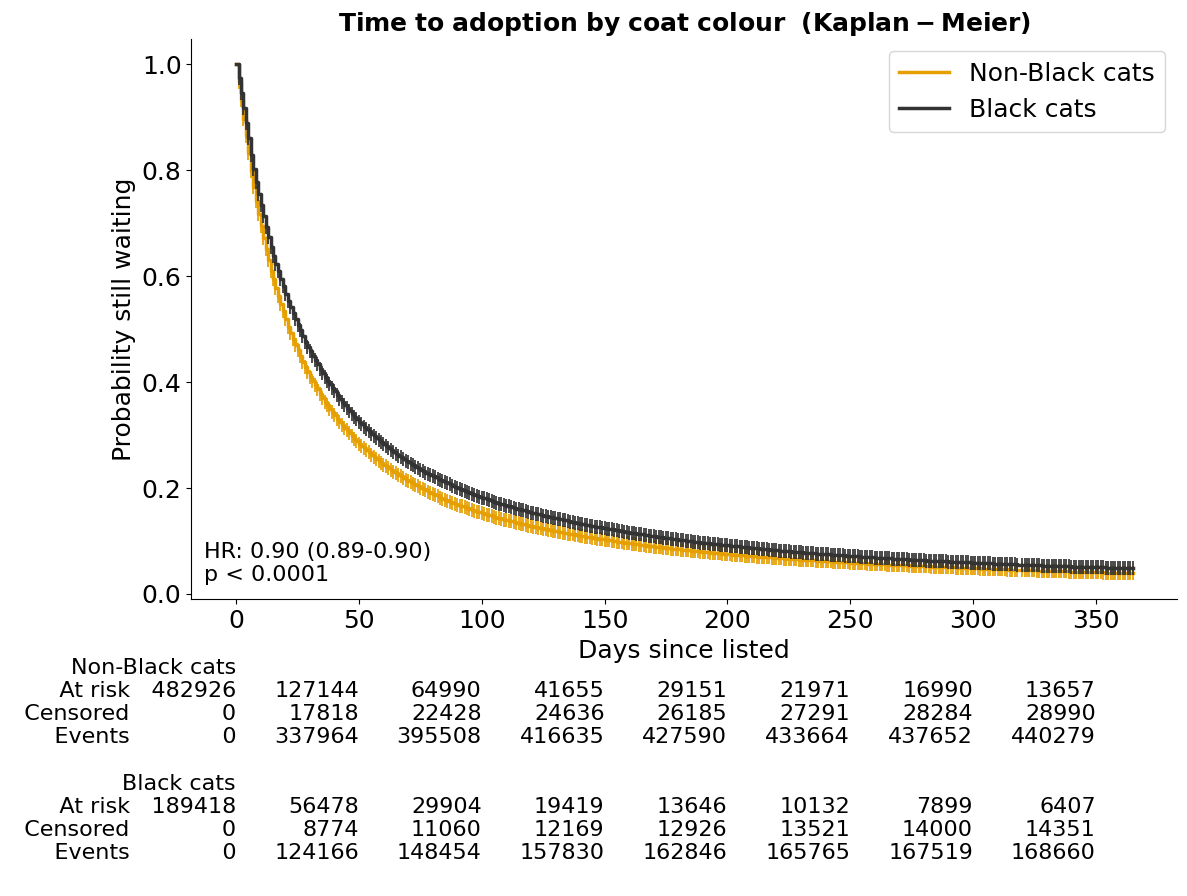


Summary Table:
            Group  Median Survival Time  % survival at 30  % survival at 60  % survival at 90  % survival at 180  % survival at 365
0  Non-Black cats                  22.0             40.99             24.38             16.79               8.35               3.85
1      Black cats                  26.0             45.80             28.23             19.96              10.18               4.75

Hazard Ratio Summary:
Hazard ratio computed using Cox univariable regression on group variable
   Hazard Ratio  95% CI Lower  95% CI Upper  P-value  Test Statistic
0           0.9          0.89           0.9      0.0          -37.85


Under the proportional hazards assumption, Cox regression is equivalent to log-rank test. See https://www.fharrell.com/post/logrank/ for more info.


,Group,Median Survival Time,% survival at 30,% survival at 60,% survival at 90,% survival at 180,% survival at 365
0,Non-Black cats,22.0,40.985336,24.378663,16.789099,8.354641,3.845784
1,Black cats,26.0,45.795296,28.234890,19.958072,10.183606,4.752035


,Hazard Ratio,95% CI Lower,95% CI Upper,P-value,Test Statistic
0,0.897342,0.892323,0.90239,0.0,-37.846483


In [ ]:
# build survival frame: 
    # adopted = event(1) @ days_to_adopt
    # adoptable = censored(0) @ days_in_shelter

# adopted
_ad = adopted.copy()
_ad['time'] = _ad['days_to_adopt']
_ad['event'] = 1

# adoptable (censor)
_ab = adoptable.copy()
_ab['time'] = pd.to_numeric(_ab['days_in_shelter'], errors='coerce')
_ab['event'] = 0

km_df = pd.concat([_ad, _ab], ignore_index=True)
km_df = km_df[(km_df['time'] >= 1) & (km_df['cohort'].isin(['Black', 'Non-Black']))].copy()
km_df['group'] = (km_df['cohort'] == 'Black').astype(int)   # 0 = Non-Black, 1 = Black

# administrative censoring
CAP = 365
_capped = km_df['time'] > CAP
km_df.loc[_capped, 'event'] = 0
km_df.loc[_capped, 'time'] = CAP

# display(km_df.iloc[:,-4:].head(10))

summary, hr = pysurv.plot_km_curve(
    km_df, time_col='time', event_col='event', group_col='group',
    group_labels=['Non-Black cats', 'Black cats'],
    colors=['#E69F00', '#333333'],
    title='Time to adoption by coat colour  (Kaplan-Meier)',
    x_label='Days since listed', 
    y_label='Probability still waiting',
    show_ci=True, survival_time_points=[30, 60, 90, 180, 365],
    return_summary=True,
)
display(summary)
display(hr)

In [71]:
# Confounder-ADJUSTED hazard ratio (Cox with controls) — the rigorous complement to PySurv's univariable HR

samp = km_df.sample(n=150_000, random_state=42).copy()
cats = ['age', 'size', 'coat', 'spayed_neutered', 'published_year']
for c in cats:
    samp[c] = samp[c].astype(str)
X = pd.concat([samp[['group']].astype(float).rename(columns={'group': 'black'}),
               pd.get_dummies(samp[cats], columns=cats, drop_first=True, dtype=float)], axis=1)
X = X.loc[:, X.nunique() > 1]
with warnings.catch_warnings():                    # heavy day-ties trip the strict MLE tol; estimate is stable
    warnings.simplefilter('ignore')
    cox = PHReg(samp['time'].values, X.values, status=samp['event'].values).fit()
hr_adj = np.exp(cox.params[list(X.columns).index('black')])

print(f"Cox PH, ADJUSTED (n=150k, +age/size/coat/spay/year): hazard ratio = {hr_adj:.3f}")
print(f"  => black cats {(1-hr_adj)*100:.1f}% lower adoption hazard, all else equal "
      f"(vs univariable ~0.90 above). Agrees with Check 4's +15-17% on days.")

Cox PH, ADJUSTED (n=150k, +age/size/coat/spay/year): hazard ratio = 0.878
  => black cats 12.2% lower adoption hazard, all else equal (vs univariable ~0.90 above). Agrees with Check 4's +15-17% on days.


> PySurv's HR
> - colour only: 0.9
> - adjusted with confounder control: 0.88

Both confirming that black cats are adopted at a lower rate.

**Caveat:** the adopted set is a 5-year *flow* and the adoptable set a single Aug-2025 *snapshot*, so they aren't one clean entry cohort - treat this as corroboration, not a separate precise number.

## Findings summary

### Verdict: YES - the penalty is real and robust to controls.

Black cats take ~15-17% longer to adopt, all else equal (median 23 vs 20 days, n≈621k, p≈0)
The survival analysis using the still-waiting cats as censored data agrees: Kaplan–Meier median 26d (Black) vs 22d, and a Cox adoption **hazard ratio of 0.88** (black cats ~12% less likely to be adopted on any given day).

- 13.5% of adopted cats sit at exactly 0 days. It is **concentrated in `Unknown`-color records** (43% of Unknown vs ~5% of Black and ~5% of Non-Black — equal)
- Black cats are not older - their age mix is nearly identical to non-black (51.9% vs 49.7% Baby; 23.4% vs 25.7% Adult). The median wait time persists within every age band: Adult +4d, Baby +3d, Senior +4d, Young +5d
- Black cats piled up in the waiting pool (33.1% still waiting vs 27.8% adopted), suggesting the adopted-only estimate **underestimates** the true penalty.
- OLS regression on `log1p(days_to_adopt)` :

| Model | Controls | Black effect | p |
|-------|----------|--------------|---|
| M0 | none (raw) | **+13.5%** longer | ~0 |
| M1 | + age | +15.1% | ~0 |
| M2 | + age, size, coat, breed-mixed, spay/neuter, state, list-year | +16.5% | ~0 |
| M3 | M2 + photo_count | +17.0% | ~0 |

Baseline medians: Black **23 days** vs Non-Black **20 days** (~+3–4 median days; larger in the mean/tail, ~+8–9 days on a ~50-day mean).